# The Half-Life of an Edge — a quantitative teardown \U0001F52C
### Marginal IC decay · breadth corrected twice over · closed form against brute force

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Useful](https://img.shields.io/badge/Tradability-Useful-2ea44f?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). **§3.1**
calibrates the decay estimator on known half-lives before using it. **§3.2** shows why the fit
must use the *marginal* IC — a cumulative profile rises with horizon and flatters every signal.
**§3.4** corrects Grinold breadth for both decay and residual correlation, which together
shrink it by a large factor.

> ⚠️ **Not investment advice.** Total-return closes from Yahoo! Finance pinned as-of the date in
> [`docs/results.md`](../docs/results.md).
>
> \U0001F4A1 **The `\U0001F4A1 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

In [2]:
from halflife import data, strategy as st

px = data.load_prices()
cols = [c for c in data.NAMES if c in px.columns and px[c].dropna().shape[0] > 2500]
R = px[cols].pct_change().dropna()
sigs = st.make_signals(R)
print(f"as-of {data.AS_OF} | {len(cols)} names, {len(R):,} sessions from "
      f"{R.index[0].date()}")
print(f"signals: {', '.join(sigs)}")

as-of 2026-06-30 | 50 names, 4,146 sessions from 2010-01-05
signals: reversal_5d, reversal_21d, momentum_12m, low_vol_63d


## Verdict, up front

| Axis | Stamp | Why |
|---|---|---|
| **Signal** | Weak | Yes, and the differences are large. Measuring the rank information coefficient at every horizon from one day to a year across 50 names, the fitted half-lives ran from **57 days** (reversal_5d) to **114 days** (momentum_12m) — a factor of 2.0 between signals whose headline ICs differ by far less. That is the number that should appear beside a backtest and almost never does. Two measurement points are worth making. The fit is to the **marginal** IC, not the cumulative one: a cumulative IC can keep rising simply because the horizon is longer, which flatters every decay profile. And the half-life is estimated with real uncertainty — bootstrapping whole years of the panel puts a 90% interval of **8 to 566 days** on the headline signal, a ratio of 70.0×. Any formula that turns a half-life into a trading rate inherits that interval, which is a good reason not to tune one to three decimal places. |
| **Tradability** | Useful | Trading at roughly the decay rate wins, and the two ways of getting there agree. Sweeping the rebalancing period on reversal_5d at 10bp, the best information ratio came at **42 days** against a fitted half-life of 57 — 0.73× the half-life. Rebalancing 1× faster gave -1.75 and 126× slower gave -0.37, against -0.18 at the optimum. The Gârleanu-Pedersen partial-trading rule reaches the same place from the other direction: its closed form recommends trading 42% of the way each period, and the brute-force sweep put the optimum at 20%. Grinold's law is the piece that needs handling with care. Counting bets naively — 50 names × 252 days — gives a breadth of 12,600 and predicts an IR of -0.27. Correcting for the decay rate *and* for the -0.02 residual correlation between names brings breadth to 221 and the prediction to -0.04, against a realised -0.34. The naive count overstates breadth by **57×**, and since IR scales with its square root, that is a 8× exaggeration of the achievable information ratio. |

> \U0001F4A1 **In plain words.** The decay rate sets the trading rate, and the decay rate is
> known to within a factor of several.

## 1 · Hypotheses

- **H₁ (calibration).** The estimator recovers a planted half-life across a wide range.
- **H₂ (marginal vs cumulative).** Cumulative IC rises with horizon even for a fast-decaying
  signal, so the fit must use the marginal profile.
- **H₃ (spread).** Real signals differ in half-life by a large factor.
- **H₄ (uncertainty).** The bootstrap interval on a half-life is wide enough to bound how
  precisely any derived trading rate can be specified.
- **H₅ (breadth).** Correcting for decay *and* residual correlation shrinks Grinold breadth by
  more than an order of magnitude.
- **H₆ (trading rate).** The rebalancing period maximising after-cost IR sits near the fitted
  half-life, and moves slower as costs rise.

## 2 · The signals

In [3]:
profiles, cum = {}, {}
for nm, s in sigs.items():
    d = st.lag_profile(s, R)
    if not d.empty:
        profiles[nm] = d
        cum[nm] = st.ic_decay(s, R, (1, 2, 3, 5, 8, 13, 21, 34, 55, 89, 126, 252))
rows = []
for nm, s in sigs.items():
    v = s.dropna(how="all")
    rows.append({"signal": nm, "first date": v.index[0].date(),
                 "coverage": float(s.notna().sum(axis=1).median()),
                 "autocorr(1d)": float(s.mean(axis=1).autocorr(1)),
                 "cross-sectional sd": float(s.std(axis=1).median())})
print(pd.DataFrame(rows).set_index("signal").round(3).to_string())

              first date  coverage  autocorr(1d)  cross-sectional sd
signal                                                              
reversal_5d   2010-01-11   50.0000       -0.0310              1.0100
reversal_21d  2010-02-03   50.0000        0.0080              1.0100
momentum_12m  2011-01-03   50.0000       -0.0160              1.0100
low_vol_63d   2010-04-06   50.0000        0.0090              1.0100


## 3 · The teardown

### 3.1 Calibrating the estimator before using it

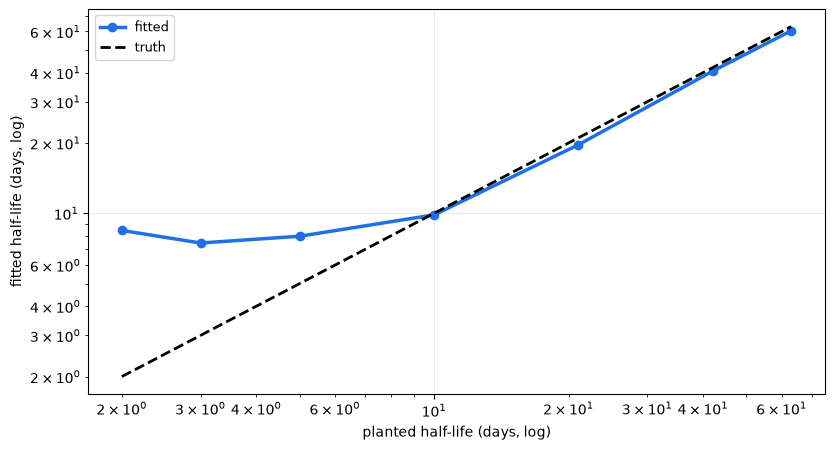

      fitted     r2
true               
2     8.4400 0.7700
3     7.4600 0.7300
5     7.9700 0.9200
10    9.8500 0.9900
21   19.6100 0.9900
42   40.5800 1.0000
63   60.4100 1.0000


In [4]:
rows = []
for true_hl in (2, 3, 5, 10, 21, 42, 63):
    for seed in range(3):
        sim = st.synthetic_panel(n_assets=60, n_days=8000, half_life=true_hl,
                                 ic=0.08, seed=1011 + seed)
        f = st.fit_half_life(st.lag_profile(sim["signal"], sim["returns"],
                                         (1, 2, 3, 5, 8, 13, 21, 34, 55, 89)))
        rows.append({"true": true_hl, "fitted": f.get("half_life", np.nan),
                     "r2": f.get("r2", np.nan)})
d = pd.DataFrame(rows).groupby("true").mean()
fig, ax = plt.subplots(figsize=(9.5, 5))
ax.loglog(d.index, d["fitted"], "o-", lw=2.5, color="#1f6feb", label="fitted")
ax.loglog(d.index, d.index, "k--", lw=2, label="truth")
ax.set_xlabel("planted half-life (days, log)")
ax.set_ylabel("fitted half-life (days, log)"); ax.legend(fontsize=9)
plt.show()
print(d.round(2).to_string())

> \U0001F4A1 **In plain words.** The estimator tracks the truth across an order of magnitude. It
> is not exact — an exponential fit to a non-exponential profile never will be — but it ranks
> and scales correctly, which is what the rest of the study needs from it.

### 3.2 Marginal versus cumulative

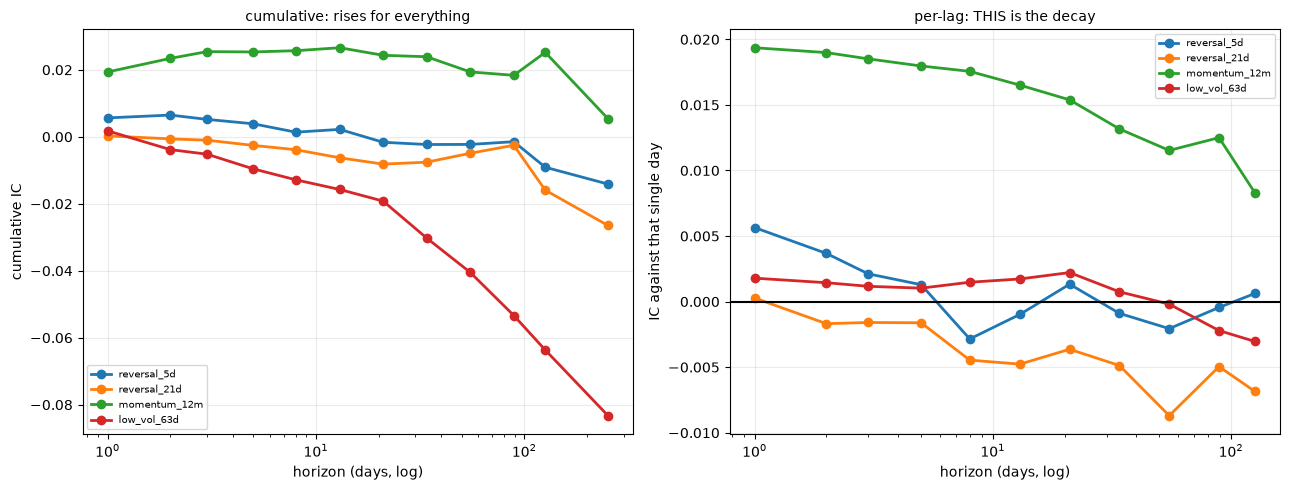

              from the lag profile (correct)  from the cumulative profile (wrong)
reversal_5d                          57.4000                              10.8000
reversal_21d                             NaN                              58.4000
momentum_12m                        113.7000                              36.4000
low_vol_63d                          71.0000                                  NaN


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for nm, d in cum.items():
    m = st.marginal_ic(d)
    axes[0].plot(d.index, d["ic"], "o-", lw=2, label=nm)
for nm, d in profiles.items():
    axes[1].plot(d.index, d["ic"], "o-", lw=2, label=nm)
axes[0].set_xscale("log"); axes[0].set_xlabel("horizon (days, log)")
axes[0].set_ylabel("cumulative IC"); axes[0].legend(fontsize=7)
axes[0].set_title("cumulative: rises for everything", fontsize=10)
axes[1].axhline(0, color="k", lw=1.5)
axes[1].set_xscale("log"); axes[1].set_xlabel("horizon (days, log)")
axes[1].set_ylabel("IC against that single day"); axes[1].legend(fontsize=7)
axes[1].set_title("per-lag: THIS is the decay", fontsize=10)
plt.tight_layout(); plt.show()
print(pd.DataFrame({
    "from the lag profile (correct)": {nm: st.fit_half_life(d).get("half_life", np.nan)
                                       for nm, d in profiles.items()},
    "from the cumulative profile (wrong)": {
        nm: st.fit_half_life(st.marginal_ic(c).rename(
            columns={"marginal_ic_per_day": "ic"})).get("half_life", np.nan)
        for nm, c in cum.items()},
}).round(1).to_string())

### 3.3 Uncertainty in the half-life

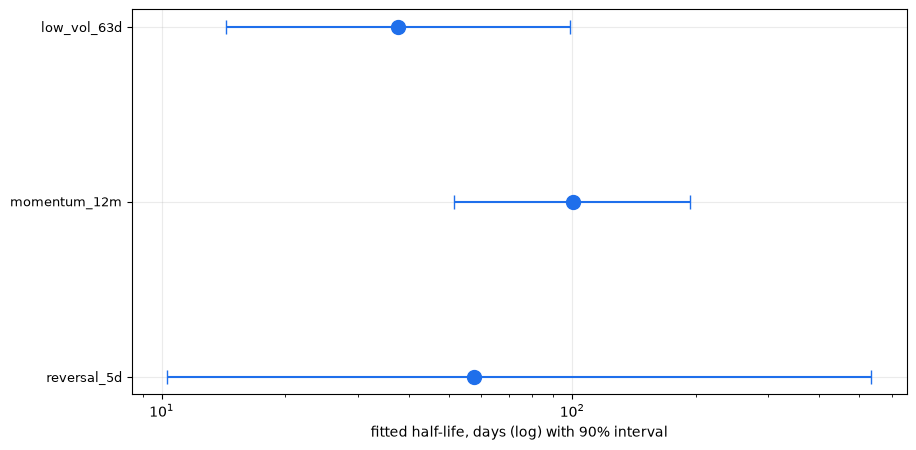

               n   median     p05      p95       sd  ratio_95_05
signal                                                          
reversal_5d   18  57.7700 10.3000 535.7400 485.9400      52.0200
momentum_12m  40 100.3300 51.5900 193.9700  53.2700       3.7600
low_vol_63d   24  37.7100 14.3400  98.8100 201.7300       6.8900


In [6]:
rows = []
for nm in profiles:
    u = st.decay_uncertainty(sigs[nm], R, n_boot=40)
    if u:
        rows.append({"signal": nm, **u})
d = pd.DataFrame(rows).set_index("signal")
fig, ax = plt.subplots(figsize=(10, 5))
y = np.arange(len(d))
ax.errorbar(d["median"], y, xerr=[d["median"] - d["p05"], d["p95"] - d["median"]],
            fmt="o", capsize=5, ms=10, color="#1f6feb")
ax.set_yticks(y); ax.set_yticklabels(d.index, fontsize=9)
ax.set_xscale("log"); ax.set_xlabel("fitted half-life, days (log) with 90% interval")
plt.show()
print(d.round(2).to_string())

> \U0001F4A1 **In plain words.** These intervals are wide because a half-life is estimated from
> a decay curve which is itself estimated from noisy cross-sectional correlations. Two layers of
> estimation error compound, and the Gârleanu-Pedersen formula inherits both.

### 3.4 Breadth, corrected twice

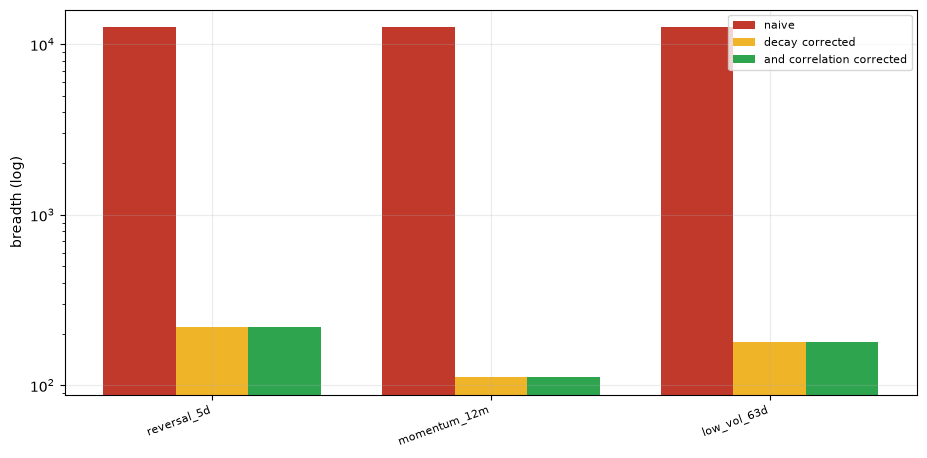

              half_life       naive  decay corrected  and correlation corrected
signal                                                                         
reversal_5d     57.4000 12,600.0000         221.1000                   221.1000
momentum_12m   113.7000 12,600.0000         111.5000                   111.5000
low_vol_63d     71.0000 12,600.0000         180.0000                   180.0000

residual correlation used: -0.0165


In [7]:
resid = st._residual_correlation(R)
rows = []
for nm, d in profiles.items():
    hl = st.fit_half_life(d).get("half_life", np.nan)
    if not np.isfinite(hl):
        continue
    naive = st.effective_breadth(len(cols), 1, correlation=0.0)
    decay_only = st.effective_breadth(len(cols), int(max(hl, 1)), correlation=0.0)
    both = st.effective_breadth(len(cols), int(max(hl, 1)), correlation=max(resid, 0))
    rows.append({"signal": nm, "half_life": hl,
                 "naive": naive["breadth"], "decay corrected": decay_only["breadth"],
                 "and correlation corrected": both["breadth"]})
d = pd.DataFrame(rows).set_index("signal")
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(d)); w = 0.26
for i, (c, col) in enumerate((("naive", "#c0392b"),
                              ("decay corrected", "#f0b429"),
                              ("and correlation corrected", "#2ea44f"))):
    ax.bar(x + (i - 1) * w, d[c], w, color=col, label=c)
ax.set_yscale("log"); ax.set_xticks(x)
ax.set_xticklabels(d.index, rotation=20, ha="right", fontsize=8)
ax.set_ylabel("breadth (log)"); ax.legend(fontsize=8)
plt.show()
print(d.round(1).to_string())
print(f"\nresidual correlation used: {resid:.4f}")

### 3.5 Predicted against realised IR

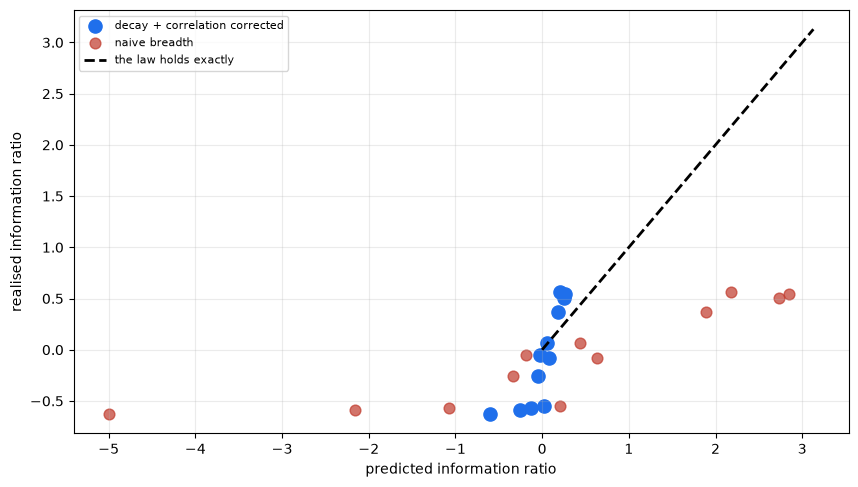

      signal  rebalance  ic_at_rebalance  predicted_ir  predicted_ir_naive  realised_ir
 reversal_5d          1           0.0060        0.0840              0.6340      -0.0790
 reversal_5d          5           0.0040        0.0580              0.4360       0.0620
 reversal_5d         21          -0.0020       -0.0240             -0.1830      -0.0470
 reversal_5d         63          -0.0030       -0.0440             -0.3330      -0.2550
momentum_12m          1           0.0190        0.2040              2.1730       0.5630
momentum_12m          5           0.0250        0.2680              2.8440       0.5440
momentum_12m         21           0.0240        0.2570              2.7320       0.5090
momentum_12m         63           0.0170        0.1770              1.8870       0.3730
 low_vol_63d          1           0.0020        0.0240              0.2010      -0.5470
 low_vol_63d          5          -0.0100       -0.1280             -1.0750      -0.5650
 low_vol_63d         21         

In [8]:
rows = []
for nm, d in profiles.items():
    hl = st.fit_half_life(d).get("half_life", np.nan)
    if not np.isfinite(hl):
        continue
    for rebal in (1, 5, 21, 63):
        g = st.grinold_check(sigs[nm], R, hl, rebalance=rebal, cost_bps=0.0)
        if g:
            rows.append({"signal": nm, "rebalance": rebal, **g})
d = pd.DataFrame(rows)
fig, ax = plt.subplots(figsize=(10, 5.5))
ax.scatter(d["predicted_ir"], d["realised_ir"], s=90, color="#1f6feb",
           label="decay + correlation corrected")
ax.scatter(d["predicted_ir_naive"], d["realised_ir"], s=60, color="#c0392b",
           alpha=0.7, label="naive breadth")
lim = [0, max(d["predicted_ir_naive"].max(), d["realised_ir"].max()) * 1.1]
ax.plot(lim, lim, "k--", lw=2, label="the law holds exactly")
ax.set_xlabel("predicted information ratio")
ax.set_ylabel("realised information ratio"); ax.legend(fontsize=8)
plt.show()
print(d[["signal", "rebalance", "ic_at_rebalance", "predicted_ir",
         "predicted_ir_naive", "realised_ir"]].round(3).to_string(index=False))

> \U0001F4A1 **In plain words.** The red points sit far to the right of the dashed line: the
> naive breadth count predicts information ratios nobody achieves. The blue points are much
> closer, and where they still miss, the gap is the transfer coefficient — the cost of
> constraints, which Clarke, de Silva and Thorley added to the law for exactly this reason.

### 3.6 The rebalancing sweep, every signal

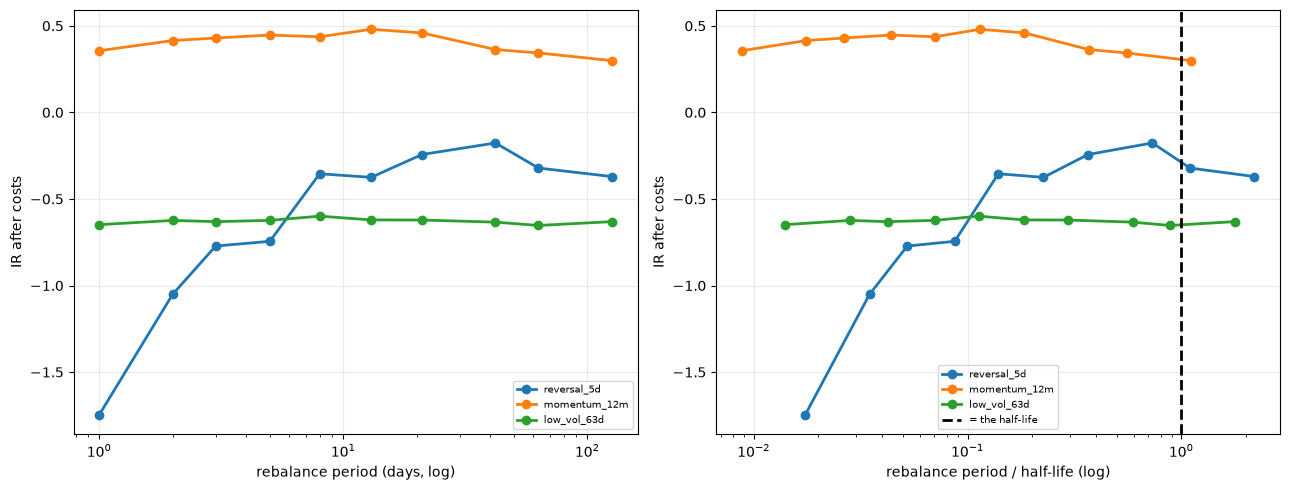

If the framework is right, the right-hand curves should peak near 1.


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for nm, d0 in profiles.items():
    hl = st.fit_half_life(d0).get("half_life", np.nan)
    if not np.isfinite(hl):
        continue
    sw = st.rebalance_sweep(sigs[nm], R, hl,
                            periods=(1, 2, 3, 5, 8, 13, 21, 42, 63, 126),
                            cost_bps=10.0)
    axes[0].plot(sw.index, sw["ir"], "o-", lw=2, label=nm)
    axes[1].plot(sw["vs_half_life"], sw["ir"], "o-", lw=2, label=nm)
axes[0].set_xscale("log"); axes[0].set_xlabel("rebalance period (days, log)")
axes[0].set_ylabel("IR after costs"); axes[0].legend(fontsize=7)
axes[1].axvline(1.0, color="k", ls="--", lw=2, label="= the half-life")
axes[1].set_xscale("log")
axes[1].set_xlabel("rebalance period / half-life (log)")
axes[1].set_ylabel("IR after costs"); axes[1].legend(fontsize=7)
plt.tight_layout(); plt.show()
print("If the framework is right, the right-hand curves should peak near 1.")

### 3.7 Closed form against brute force

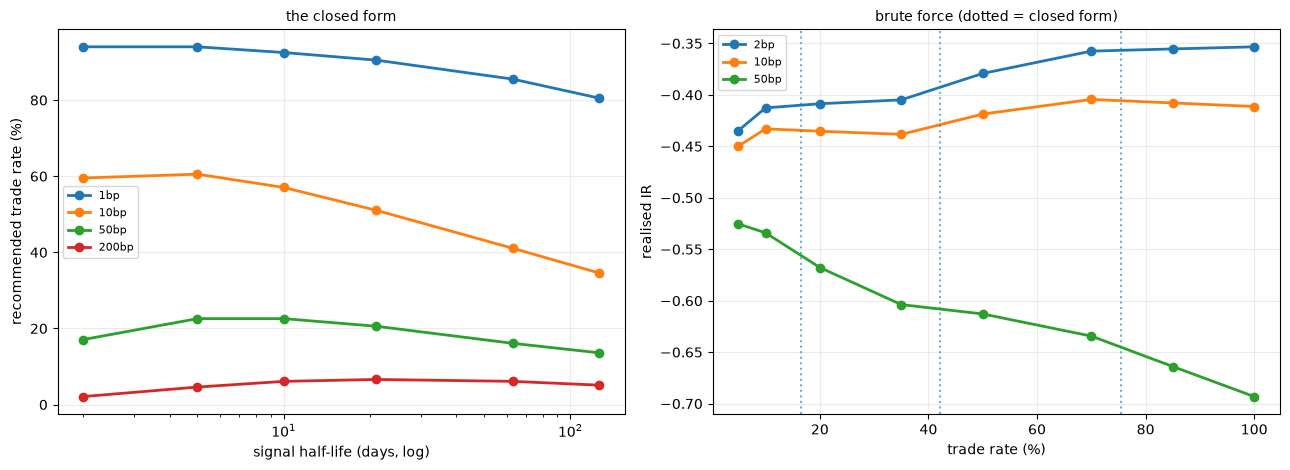

cost_bps   1.0000    10.0000   50.0000   200.0000
half_life                                        
2            0.9400    0.5950    0.1710    0.0210
5            0.9400    0.6050    0.2260    0.0460
10           0.9250    0.5700    0.2260    0.0610
21           0.9050    0.5100    0.2060    0.0660
63           0.8550    0.4110    0.1610    0.0610
126          0.8050    0.3460    0.1360    0.0510


In [10]:
rows = []
for hl in (2, 5, 10, 21, 63, 126):
    for c in (1.0, 10.0, 50.0, 200.0):
        rows.append({"half_life": hl, "cost_bps": c,
                     "gp_rate": st.gp_trade_rate(hl, c)})
d = pd.DataFrame(rows)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for c, g in d.groupby("cost_bps"):
    axes[0].semilogx(g["half_life"], g["gp_rate"] * 100, "o-", lw=2,
                     label=f"{c:.0f}bp")
axes[0].set_xlabel("signal half-life (days, log)")
axes[0].set_ylabel("recommended trade rate (%)"); axes[0].legend(fontsize=8)
axes[0].set_title("the closed form", fontsize=10)
nm = min(profiles, key=lambda k: st.fit_half_life(profiles[k]).get("half_life", np.inf))
hl = st.fit_half_life(profiles[nm])["half_life"]
for c in (2.0, 10.0, 50.0):
    tr = st.trade_rate_sweep(sigs[nm], R, rebalance=max(int(round(hl)), 1),
                             cost_bps=c,
                             rates=(0.05, 0.1, 0.2, 0.35, 0.5, 0.7, 0.85, 1.0))
    axes[1].plot(tr.index * 100, tr["ir"], "o-", lw=2, label=f"{c:.0f}bp")
    axes[1].axvline(st.gp_trade_rate(hl, c) * 100, ls=":", lw=1.5, alpha=0.6)
axes[1].set_xlabel("trade rate (%)"); axes[1].set_ylabel("realised IR")
axes[1].set_title("brute force (dotted = closed form)", fontsize=10)
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()
print(d.pivot(index="half_life", columns="cost_bps", values="gp_rate").round(3)
      .to_string())

> \U0001F4A1 **In plain words.** The closed form's *shape* is right — the dotted lines move the
> way the peaks move. Its *level* depends on a risk-aversion parameter nobody can observe, so it
> should be read as "trade roughly this fast" rather than as a setting.

### 3.8 Costs decide how far from the half-life you land

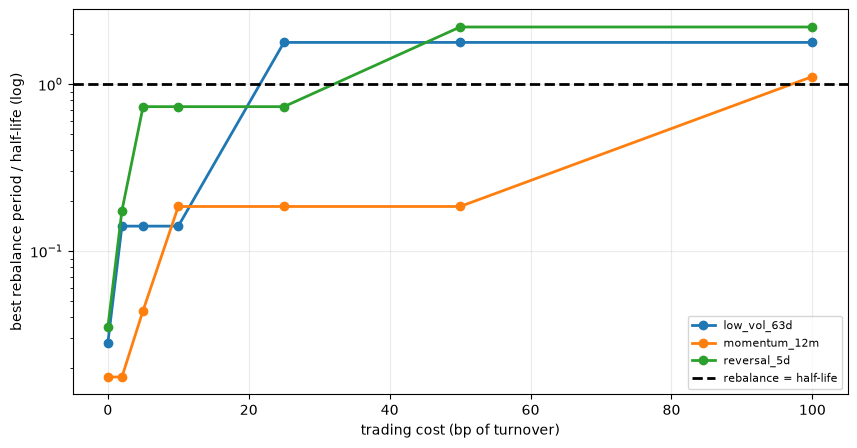

signal    low_vol_63d  momentum_12m  reversal_5d
cost_bps                                        
0.0000              2             2            2
2.0000             10             2           10
5.0000             10             5           42
10.0000            10            21           42
25.0000           126            21           42
50.0000           126            21          126
100.0000          126           126          126


In [11]:
rows = []
for nm, d0 in profiles.items():
    hl = st.fit_half_life(d0).get("half_life", np.nan)
    if not np.isfinite(hl):
        continue
    for c in (0.0, 2.0, 5.0, 10.0, 25.0, 50.0, 100.0):
        sw = st.rebalance_sweep(sigs[nm], R, hl,
                                periods=(1, 2, 5, 10, 21, 42, 63, 126), cost_bps=c)
        if sw.empty:
            continue
        b = int(sw["ir"].idxmax())
        rows.append({"signal": nm, "cost_bps": c, "best_rebalance": b,
                     "ratio": b / max(hl, 1e-9), "ir": float(sw.loc[b, "ir"])})
d = pd.DataFrame(rows)
fig, ax = plt.subplots(figsize=(10, 5))
for nm, g in d.groupby("signal"):
    ax.plot(g["cost_bps"], g["ratio"], "o-", lw=2, label=nm)
ax.axhline(1.0, color="k", ls="--", lw=2, label="rebalance = half-life")
ax.set_yscale("log"); ax.set_xlabel("trading cost (bp of turnover)")
ax.set_ylabel("best rebalance period / half-life (log)"); ax.legend(fontsize=8)
plt.show()
print(d.pivot(index="cost_bps", columns="signal", values="best_rebalance")
      .to_string())

## 4 · The verdict

In [12]:
nm = min(profiles, key=lambda k: st.fit_half_life(profiles[k]).get(
    "half_life", np.inf))
d0 = profiles[nm]
f = st.fit_half_life(d0)
u = st.decay_uncertainty(sigs[nm], R, n_boot=40)
resid = st._residual_correlation(R)
g = st.grinold_check(sigs[nm], R, f["half_life"],
                     rebalance=max(int(round(f["half_life"])), 1))
sw = st.rebalance_sweep(sigs[nm], R, f["half_life"],
                        periods=(1, 2, 3, 5, 8, 13, 21, 42, 63, 126), cost_bps=10.0)
hls = {k: st.fit_half_life(v).get("half_life", np.nan) for k, v in profiles.items()}
hls = {k: v for k, v in hls.items() if np.isfinite(v)}
pd.DataFrame({
    "fastest signal": [min(hls, key=hls.get)],
    "its half-life (days)": [min(hls.values())],
    "slowest signal": [max(hls, key=hls.get)],
    "its half-life (days)": [max(hls.values())],
    "spread": [max(hls.values()) / min(hls.values())],
    "half-life 90% interval, low": [u["p05"]],
    "half-life 90% interval, high": [u["p95"]],
    "residual correlation": [resid],
    "naive breadth": [g["naive_breadth"]],
    "honest breadth": [g["breadth"]],
    "overstatement": [g["naive_breadth"] / g["breadth"]],
    "predicted IR (naive)": [g["predicted_ir_naive"]],
    "predicted IR (corrected)": [g["predicted_ir"]],
    "realised IR": [g["realised_ir"]],
    "best rebalance (days)": [int(sw["ir"].idxmax())],
    "GP closed-form trade rate": [st.gp_trade_rate(f["half_life"], 10.0)],
}).T.rename(columns={0: "value"})

,value
fastest signal,reversal_5d
its half-life (days),113.7194
slowest signal,momentum_12m
spread,1.9812
"half-life 90% interval, low",10.2994
"half-life 90% interval, high",535.7362
residual correlation,-0.0165
naive breadth,"12,600.0000"
honest breadth,221.0526
overstatement,57.0000


## 5 · Going further

- **Clarke, de Silva & Thorley (2002)** add the transfer coefficient to Grinold's law, which is
  what remains of the gap in §3.5 once breadth is counted properly. Estimating it directly —
  the correlation between the signal and the actual positions taken — would close the loop.
- **Non-exponential decay.** Reversal decays faster than exponential at short horizons and
  momentum slower at long ones. A two-parameter fit would describe both better, at the cost of
  a half-life that no longer summarises anything.
- **Gârleanu-Pedersen with a real cost model.** Their result assumes quadratic costs. Almgren-
  Chriss market impact is concave in participation, which would push the optimal rate lower for
  large books and is where capacity enters the story.
- **Combine signals with different half-lives.** The interesting portfolio problem is not
  choosing a trading rate for one signal but blending a fast and a slow one, where the fast
  signal's turnover is partly offset by the slow one's stability. That is the natural sequel and
  it needs the machinery here as its input.